---
---

# Detecting Phishing URLs with Deep Learning
---
---

* Goal: detecting wether a website url is for a spam or a real website 
* Data: labeled dataset with both kinds of urls
* Value: phishig websites are getting better and a lot of people do not have the technical knowledge to decide for themselves or click on urls on accident or out of panic --> protect people
* Lots of phishing urls aim to get either personal information or money --> project aims to prevent that through automatically being able to detect wether a url is phishing or not

# Imports and Settings
---

In [1]:
import pandas as pd 
# display all columns
pd.options.display.max_columns = None 

# splitting and scaling the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# metrics and baseline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score

# deep learning 
import torch 
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import copy 

# Plotting and visualization
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

 # set once, mitigate randomness 
torch.manual_seed(42)

# Project Tasks
---

# Task 1 -The Data

Presentation of the raw data, the features and interesting properties

In [2]:
raw_data = pd.read_csv("Dataset.csv")

Dataset source and copyright:
* **Kaggle link**: https://www.kaggle.com/datasets/sahandnamvar/phishing-url-detection-111k-urls-22-features
* **Dataset citation:**\
Dam Minh, Linh; Tran Cong, Hung (2025).\
URL-Phish: A Feature-Engineered Dataset for Phishing Detection.\
Mendeley Data, V1.\
DOI: https://doi.org/10.17632/65z9twcx3r.1
* **Copyright:** creative commons CC BY 4.0 https://creativecommons.org/licenses/by/4.0/
* **Additional paper:** https://www.sciencedirect.com/science/article/pii/S2352340925008832?via%3Dihub (source for column explanations)

In [3]:
raw_data.head()

,url,url_len,dom,dom_len,is_ip,tld,tld_len,subdom_cnt,letter_cnt,digit_cnt,special_cnt,eq_cnt,qm_cnt,amp_cnt,dot_cnt,dash_cnt,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
0,https://www.rmit.edu.au/,24,rmit.edu.au,11,0,edu.au,6,1,17,0,7,0,0,0,3,0,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0
1,http://www.latrobe.edu.au/,26,latrobe.edu.au,14,0,edu.au,6,1,19,0,7,0,0,0,3,0,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0
2,https://www.cqu.edu.au/,23,cqu.edu.au,10,0,edu.au,6,1,16,0,7,0,0,0,3,0,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0
3,http://bond.edu.au/,19,bond.edu.au,11,0,edu.au,6,0,13,0,6,0,0,0,2,0,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0
4,http://www.csu.edu.au/,22,csu.edu.au,10,0,edu.au,6,1,15,0,7,0,0,0,3,0,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0


In [4]:
raw_data["tld"].nunique()

1257

In [5]:
raw_data.describe()

,url_len,dom_len,is_ip,tld_len,subdom_cnt,letter_cnt,digit_cnt,special_cnt,eq_cnt,qm_cnt,amp_cnt,dot_cnt,dash_cnt,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label
count,116600.000000,116600.000000,116600.000000,116600.000000,116600.000000,116600.00000,116600.000000,116600.000000,116600.000000,116600.000000,116600.000000,116600.000000,116600.00000,116600.000000,116600.000000,116600.000000,116600.000000,116600.000000,116600.000000,116600.000000,116600.000000,116600.000000,116600.000000
mean,32.952521,12.845763,0.000111,3.320223,0.845669,25.00681,0.943988,7.001724,0.079537,0.038379,0.040866,2.148988,0.34169,0.053799,0.752510,0.013126,0.234364,0.431141,3.215026,3.863736,6.391381,1.600575,0.142367
std,29.369989,5.140745,0.010558,1.418215,0.480620,22.39638,5.947690,3.995755,0.492609,0.199942,0.359917,0.750565,0.97824,0.483712,0.059062,0.047709,0.052906,0.495238,0.930527,0.359595,17.589086,19.273675,0.349428
min,12.000000,4.000000,0.000000,0.000000,0.000000,4.00000,0.000000,4.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.144928,0.000000,0.012998,0.000000,2.000000,2.653544,0.000000,0.000000,0.000000
25%,22.000000,9.000000,0.000000,2.000000,1.000000,16.00000,0.000000,6.000000,0.000000,0.000000,0.000000,2.000000,0.00000,0.000000,0.714286,0.000000,0.194444,0.000000,3.000000,3.642490,1.000000,0.000000,0.000000
50%,27.000000,11.000000,0.000000,3.000000,1.000000,20.00000,0.000000,6.000000,0.000000,0.000000,0.000000,2.000000,0.00000,0.000000,0.750000,0.000000,0.236842,0.000000,3.000000,3.831402,1.000000,0.000000,0.000000
75%,34.000000,16.000000,0.000000,3.000000,1.000000,27.00000,0.000000,7.000000,0.000000,0.000000,0.000000,3.000000,0.00000,0.000000,0.793103,0.000000,0.272727,1.000000,3.000000,4.027169,4.000000,0.000000,0.000000
max,1202.000000,62.000000,1.000000,22.000000,7.000000,1037.00000,321.000000,234.000000,29.000000,17.000000,27.000000,15.000000,25.00000,20.000000,0.936000,0.826087,0.523810,1.000000,37.000000,6.032729,670.000000,1148.000000,1.000000


Table of columns with explanations:

* The dataset has various features on lexical information about the urls
* The below table shows the ranges the values take in the dataset and explanations for the features
* min and max values are derived from the above table and still include potential outliers


| Feature | Data Type | Range  | Explanation |
|---------|-----------|--------|-------------|
|url  | string | unique values(strings) | Url of the website    |
|url_len  | integer |12-1202| Length of the url     |
|dom  | string | strings| extracted domain name     |
|dom_len  | integer | 4-62| Length of the domain     |
|is_ip  | binary | 0 or 1| if the domain is an IP address    |
|tld  |string | 1257 domains (strings)|  extracted top-level domain  |
|tld_len  | integer |0-22| length of the top level domain  |
|subdom_cnt | integer |0-7| number of subdomains in the url |
|letter_cnt | integer |4-1037| Amount of alphabetical characters in the url   |
|digit_cnt | integer |0-321| Amount of numeric characters in the url   |
|special_cnt | integer |4-234| Amount of special characters in the url  |
|eq_cnt  | integer |0-29| Number of equal signs in the url   |
|qm_cnt | integer  |0-17| Number of question marks in the url   |
|amp_cnt | integer |0-27| Number of ampersands (&) in the url   |
|dot_cnt | integer |1-15| Amount of dots in the url  |
|dash_cnt | integer  |0-25| Amount of dashes in the url  |
|under_cnt | integer |0-20| Amount of underscores in the url  |
|letter_ratio | float |0.15-0.94| Ratio of letters to other characters in the url   |
|digit_ratio | float  |0.00-0.83| Ratio of digits to other characters in the url   |
|spec_ratio | float  |0.01-0.52| Ratio of special characters to other characters in the url   |
|is_https | binary |0 or 1| True or False wether url is https   |
|slash_cnt | integer |2-37| Amount of slashes in the url  |
|entropy | float  |2.65-6.03|Shannon entropy of the URL string (higher = more randomness)|
|path_len | integer |0-670| Length of the URL path |
|query_len | integer |0-1148| Length of the query string |
|label | binary |0 or 1| Target variable, phishing (1) url or not (0) |

**Suitability of the dataset:**

* real world data
* large amount of samples 
* even though there is an imbalance in the target, sufficient samples of both categories, and it refelcts real world situation
* non-phishing and phishing urls clearly labeled 
* lots of lexical features --> training with deep learning possible
* featuers like url, dom and tld for interpretability
* dataset is well documented

# Task 2 - Initial Data Analysis

Initial data analysis of the raw data

In [6]:
# shape of the data
raw_data.shape

(116600, 26)

In [7]:
# data types of columns
raw_data.dtypes

url              object
url_len           int64
dom              object
dom_len           int64
is_ip             int64
tld              object
tld_len           int64
subdom_cnt        int64
letter_cnt        int64
digit_cnt         int64
special_cnt       int64
eq_cnt            int64
qm_cnt            int64
amp_cnt           int64
dot_cnt           int64
dash_cnt          int64
under_cnt         int64
letter_ratio    float64
digit_ratio     float64
spec_ratio      float64
is_https          int64
slash_cnt         int64
entropy         float64
path_len          int64
query_len         int64
label             int64
dtype: object

**Observation:** the dataset has 116600 instances and 26 features, one of them being the binary target label. The other 25 features inlcude 22 numerical featueres and 3 categorical features that are mainly for interpretability

In [8]:
# nan values
raw_data.isna().sum()

url              0
url_len          0
dom              0
dom_len          0
is_ip            0
tld             14
tld_len          0
subdom_cnt       0
letter_cnt       0
digit_cnt        0
special_cnt      0
eq_cnt           0
qm_cnt           0
amp_cnt          0
dot_cnt          0
dash_cnt         0
under_cnt        0
letter_ratio     0
digit_ratio      0
spec_ratio       0
is_https         0
slash_cnt        0
entropy          0
path_len         0
query_len        0
label            0
dtype: int64

In [9]:
# duplicates
raw_data.duplicated().sum()

np.int64(1369)

In [10]:
# looking at unique values, special interest in categorical data
raw_data.nunique()

url             115231
url_len            341
dom              90860
dom_len             47
is_ip                2
tld               1257
tld_len             22
subdom_cnt           7
letter_cnt         287
digit_cnt          129
special_cnt         75
eq_cnt              17
qm_cnt               5
amp_cnt             15
dot_cnt             13
dash_cnt            23
under_cnt           18
letter_ratio      1750
digit_ratio       1464
spec_ratio        1106
is_https             2
slash_cnt           19
entropy          14800
path_len           175
query_len          245
label                2
dtype: int64

**Observation:** there are 14 nan values in the tld column and the dataset contains 1369 duplicated rows. Both will be handled in the preprocessing in task 3. Furthermore, the above table shows how many unique values each column has. Especially the categorical columns have a high number of unique values which will be further addressed in the preprocessing step in Task 3.

In [11]:
# distribution of labels
raw_data["label"].value_counts()

label
0    100000
1     16600
Name: count, dtype: int64

**Observation:** There is an imbalance between the two target labels, with 100.000 benign website urls and 16600 phishing urls. This will be addressed in the various further steps of the poject. For further statistical analysis of the other featuers, the statistical distribution table was provided in Task 3 and further visualizations will be provided in the exploratory data analysis in task 4.

# Task 3 - Preprocessing

This section contains several preprocessing steps to get the data ready for deep learning experiments

## 1. Drop duplicates, features and rows with nan values

In [12]:
raw_data["is_ip"].value_counts()

is_ip
0    116587
1        13
Name: count, dtype: int64

In [13]:
# first drop all duplicates
raw_data.drop_duplicates(inplace=True)

In [14]:
# drop rows with nan values
raw_data.dropna(inplace=True)

In [15]:
raw_data["is_ip"].value_counts()

is_ip
0    115217
Name: count, dtype: int64

In [16]:
# drop features
raw_data.drop(columns=["url", "dom", "is_ip"], inplace=True)

**Explanation:** 
To begin with, I have dropped all duplicate rows in the dataset. Furthermore, I have dropped all rows with nan values, as there are only 14 and that is inconsequential compared to the size of the full dataset. I have dropped the column url because it is unique and I do not need it, as it is only an identifier and has no prediction value. Furthermore, I have dropped the domain name as it is also more for interpretability and there are over 90 thousand different ones, meaning there is not a lof of value in the column. Additionally, I have dropped the column is_ip. Apparently there were only 13 instances with the value 1, all others being 0. Those coincidently got dropped when removing duplicates and nan values. Therefore, I am dropping the whole column, as it is constant after preprocessing. (this appeared when checking the correlations in task 3, EDA, so I went back to preprocess further.) This also did not change my decision on dropping rows with nan values or duplicates, as the column was almost constant before, which means that it is not useful for deep learning experiments. 

## 2. Encode columns where neccessary

**Explanation:** I have decided to inlcude the top level domain in the project because there are not as many unique values as for example in the domain name feature. Furthermore, I think it is possible that there are top level domains that are more prone to being phishing. Therefore, I want to include this feature in my project. But since there are a lot of different tlds that explode the dimensionality of the dataset, I have decided to group the rare tlds into one group called "other", as rare categories could introduce noice. I have decided to use the top 50 tlds and have an eleventh group called "other", as the 50 top tlds cover almost 82% of all instances in the dataset. Therefore, not too many samples are being compressed into "other", meaning that the column can still be learnt from. On the other hand, 51 columns after encoding is much easier to handle compared to over 1200 columns without the grouping of rarer tlds.

In [17]:
# checking percentage of instances in top tlds to decide for filter 
top_n = 50
tld_counts = raw_data["tld"].value_counts()
coverage = tld_counts.head(top_n).sum() / len(raw_data)
print(f"Top {top_n} TLDs cover {coverage:.2%} of the dataset")

Top 50 TLDs cover 81.59% of the dataset


In [18]:
top_tlds = raw_data["tld"].value_counts().nlargest(50).index
raw_data["tld_grouped"] = raw_data["tld"].where(raw_data['tld'].isin(top_tlds), "other")
raw_data.drop(columns=["tld"], inplace=True)

In [19]:
# encoding the filtered tld column
raw_data=pd.get_dummies(raw_data, drop_first=True)

In [20]:
# True/False to 1/0 for EDA
raw_data[raw_data.select_dtypes("bool").columns] = raw_data.select_dtypes("bool").astype(int)

## 3. Short analysis of the final dataset

In [21]:
# shape of the processed data
raw_data.shape

(115217, 72)

In [22]:
raw_data["label"].value_counts()

label
0    98634
1    16583
Name: count, dtype: int64

**Observation:**
The dataset now has more columns (72 as opposed to 26 in the beginning) due to the dummification of the data. Furthermore, there are 115217 instances left after dropping some due to duplicates or nan values. The distribution of labels in the target is now 98634 for the benign urls and 16582 for the phishing urls. This means both labels have less instances now, but more instances were removed from the benign group, which is good, as there were a lot more instances to begin with. I have decided to not handle the class imbalance with methods like upsampling, as I am planning to use other methods, like balanced accuracy as a metric, to mitigate the influence of imbalanced data. 

In [23]:
# final, preprocessed dataset
data = raw_data

In [24]:
# examples of the preprocessed data
data.head()

,url_len,dom_len,tld_len,subdom_cnt,letter_cnt,digit_cnt,special_cnt,eq_cnt,qm_cnt,amp_cnt,dot_cnt,dash_cnt,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label,tld_grouped_ac.in,tld_grouped_ac.jp,tld_grouped_ac.uk,tld_grouped_app,tld_grouped_at,tld_grouped_be,tld_grouped_ca,tld_grouped_ch,tld_grouped_cn,tld_grouped_co,tld_grouped_co.jp,tld_grouped_co.uk,tld_grouped_com,tld_grouped_com.au,tld_grouped_com.br,tld_grouped_com.cn,tld_grouped_cz,tld_grouped_de,tld_grouped_dev,tld_grouped_dk,tld_grouped_edu,tld_grouped_edu.cn,tld_grouped_es,tld_grouped_eu,tld_grouped_fi,tld_grouped_fr,tld_grouped_gov,tld_grouped_gr,tld_grouped_ie,tld_grouped_io,tld_grouped_it,tld_grouped_jp,tld_grouped_ly,tld_grouped_me,tld_grouped_net,tld_grouped_nhs.uk,tld_grouped_nl,tld_grouped_no,tld_grouped_or.jp,tld_grouped_or.kr,tld_grouped_org,tld_grouped_org.au,tld_grouped_org.uk,tld_grouped_other,tld_grouped_pl,tld_grouped_pt,tld_grouped_ru,tld_grouped_se,tld_grouped_shop,tld_grouped_sk
0,24,11,6,1,17,0,7,0,0,0,3,0,0,0.708333,0.0,0.291667,1,3,3.709148,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,26,14,6,1,19,0,7,0,0,0,3,0,0,0.730769,0.0,0.269231,0,3,3.738149,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,23,10,6,1,16,0,7,0,0,0,3,0,0,0.695652,0.0,0.304348,1,3,3.609668,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,19,11,6,0,13,0,6,0,0,0,2,0,0,0.684211,0.0,0.315789,0,3,3.576618,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,22,10,6,1,15,0,7,0,0,0,3,0,0,0.681818,0.0,0.318182,0,3,3.503998,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


# Task 4 - Exploratory Data Analysis

Several visualizations about interesting aspects and relationships in the data

## Visualization 1 - Correlations

The focus is on the correlation of selected features with the target label

In [25]:
# correlation between all colummns 
data.corr()

,url_len,dom_len,tld_len,subdom_cnt,letter_cnt,digit_cnt,special_cnt,eq_cnt,qm_cnt,amp_cnt,dot_cnt,dash_cnt,under_cnt,letter_ratio,digit_ratio,spec_ratio,is_https,slash_cnt,entropy,path_len,query_len,label,tld_grouped_ac.in,tld_grouped_ac.jp,tld_grouped_ac.uk,tld_grouped_app,tld_grouped_at,tld_grouped_be,tld_grouped_ca,tld_grouped_ch,tld_grouped_cn,tld_grouped_co,tld_grouped_co.jp,tld_grouped_co.uk,tld_grouped_com,tld_grouped_com.au,tld_grouped_com.br,tld_grouped_com.cn,tld_grouped_cz,tld_grouped_de,tld_grouped_dev,tld_grouped_dk,tld_grouped_edu,tld_grouped_edu.cn,tld_grouped_es,tld_grouped_eu,tld_grouped_fi,tld_grouped_fr,tld_grouped_gov,tld_grouped_gr,tld_grouped_ie,tld_grouped_io,tld_grouped_it,tld_grouped_jp,tld_grouped_ly,tld_grouped_me,tld_grouped_net,tld_grouped_nhs.uk,tld_grouped_nl,tld_grouped_no,tld_grouped_or.jp,tld_grouped_or.kr,tld_grouped_org,tld_grouped_org.au,tld_grouped_org.uk,tld_grouped_other,tld_grouped_pl,tld_grouped_pt,tld_grouped_ru,tld_grouped_se,tld_grouped_shop,tld_grouped_sk
url_len,1.000000,0.117867,0.014313,0.105958,0.971985,0.764098,0.765396,0.638371,0.499395,0.591716,0.200959,0.553383,0.568855,0.120058,0.366106,-0.463916,0.162388,0.504246,0.653084,0.707970,0.766378,0.323657,-0.014760,-0.011330,-0.007413,0.019307,-0.005687,-0.008586,-0.010173,-0.003897,-0.000253,0.002277,-0.002606,-0.006514,0.113638,0.005641,0.006820,-0.009078,-0.032295,0.000041,0.047709,-0.007004,-0.046991,-0.017823,-0.003714,-0.017991,-0.003169,0.014766,0.017726,-0.009028,-0.008998,0.024035,-0.009250,-0.011815,-0.025399,0.019228,-0.006519,0.075480,-0.015393,-0.023236,-0.005897,-0.003246,-0.058778,-0.006067,-0.009564,-0.025040,-0.016346,-0.010343,-0.034328,-0.010686,0.033825,-0.015952
dom_len,0.117867,1.000000,0.166721,-0.122876,0.157746,0.000860,-0.018943,-0.031290,-0.037108,-0.021372,-0.049696,0.079402,-0.010274,0.532985,-0.021979,-0.573993,-0.053080,-0.085149,0.276660,-0.061702,0.007059,-0.080431,0.006620,0.011763,-0.009603,-0.038789,-0.011334,-0.023812,-0.016834,-0.028868,-0.080290,-0.075599,0.006952,0.068910,0.131951,0.045335,0.051356,-0.003671,-0.068881,0.008088,-0.090896,-0.003325,-0.083619,-0.023833,-0.038050,-0.028035,-0.014454,-0.024949,-0.104048,-0.024140,-0.022638,-0.039438,-0.017721,-0.008753,-0.110417,-0.059113,-0.002957,0.037930,-0.002019,-0.027785,0.008203,-0.011058,0.137840,0.033778,0.077502,-0.054982,-0.037327,-0.027200,-0.098200,-0.009155,0.103634,-0.034838
tld_len,0.014313,0.166721,1.000000,0.013899,0.010512,-0.020727,0.077150,-0.024018,-0.021696,-0.016278,0.504889,-0.033985,-0.001706,-0.056761,-0.044289,0.103180,-0.055310,-0.007743,0.018145,0.000296,-0.012318,-0.118147,0.070567,0.115899,0.077314,-0.014016,-0.048984,-0.053969,-0.099657,-0.086942,-0.089752,-0.054318,0.075401,0.115421,-0.143039,0.100580,0.138235,0.116683,-0.129434,-0.171030,-0.024528,-0.053547,-0.042075,0.144182,-0.074946,-0.079333,-0.050947,-0.130782,-0.027409,-0.050947,-0.053194,-0.054733,-0.094282,-0.061313,-0.078949,-0.054940,-0.025089,0.172548,-0.086458,-0.096570,0.081233,0.068023,-0.095509,0.108141,0.187761,0.498836,-0.064736,-0.054940,-0.121914,-0.080240,0.026334,-0.048830
subdom_cnt,0.105958,-0.122876,0.013899,1.000000,0.099013,0.035465,0.171130,0.031448,0.018253,0.039209,0.681957,0.064718,0.023295,-0.044339,0.015114,0.035769,-0.104243,0.052258,0.109698,0.053218,0.004539,-0.101463,-0.019685,0.044417,0.037389,0.017582,0.002923,0.008741,-0.012869,0.028376,0.006627,-0.052605,0.015502,-0.000053,-0.034046,-0.011176,-0.004940,0.017925,0.028896,0.024959,0.040079,-0.010300,0.050771,0.029164,0.034734,-0.001202,-0.001460,0.060975,0.129131,0.010073,0.001068,-0.008347,0.053113,-0.000691,-0.148388,0.014755,0.008002,0.012293,0.003985,-0.009113,0.028489,0.007615,-0.085720,-0.010424,-0.009802,-0.012225,0.019312,0.019341,-0.013760,-0.011917,0.011925,0.009013
letter_cnt,0.971985,0.157746,0.010512,0.099013,1.000000,0.608266,0.634535,0.607986,0.481514,0.565910,0.188680,0.549106,0.571744,0.249770,0.262050,-0.514594,0.166496,0.510576,0.670056,0.647657,0.77400

**Observation:** There are too many columns to plot a interpretable correlation heatmap. Because of this, I will only show the top 15 features (which is a bit more than 20% of features) with the highest absolute (meaning absolute values, e.g. high positive or negative correlation) correlation as to make the heatmap more meaningful. For this, I am using the correlation of the features with the target, meaning the label column, as the goal of the project is to predict a label. This means the correlation of features with the label is the most important. Therefore, which 15 features to include in the heatmap is based on how strong their correlation with the target feature is.

In [26]:
# get correlation with label
corr = data.corr()
target_corr = corr["label"].abs().sort_values(ascending=False)
print(target_corr)

label                 1.000000
digit_ratio           0.518343
entropy               0.513606
is_https              0.400515
spec_ratio            0.385565
                        ...   
tld_grouped_at        0.017370
tld_grouped_com.au    0.011235
tld_grouped_net       0.009898
tld_grouped_com.br    0.009799
tld_grouped_other     0.003974
Name: label, Length: 72, dtype: float64


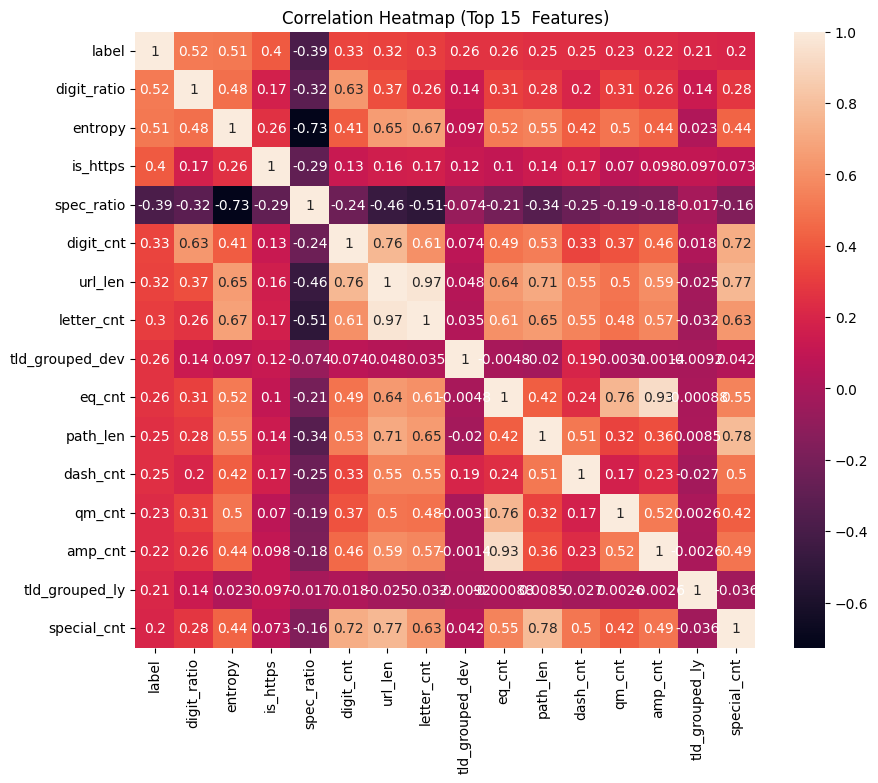

In [27]:
# select top features to not overcrowd visualization
top_features = target_corr.index[0:16]  # top 15 + label (index 0, as it has corr of 1.0)
plt.figure(figsize=(10,8))
sns.heatmap(data[top_features].corr(), annot=True)
plt.title("Correlation Heatmap (Top 15  Features)")
plt.show()

**Observation:** Since absolute values were only used for the ranking, but actual values for the heatmap, this shows that most of the top correlations happen to be positive, which can be seen in the lighter coloring. One feature that sticks out is spec_ratio, as it is the only one with a negative correlation. This means a higher spec_ratio is an indication that a url is less likely to be phishing, as a strong negative correlation means a higher likelyhood for label 0, which in this case is the not phishing label. The strongest correlation is with digit_ratio at 0.52. This is a moderate correlation. In total, the correlations are not very high and range in a low to moderate range, especially considering that these are the top 15 correlations, meaning that all other features are less correlated with the target. Therefore, a combination of features are needed to predict wether a url is phishing or not, making a deep learning approach suitable for this project.

## Visualization 2 - Feature distributions

Presentation of the value distributions of the previously selected features

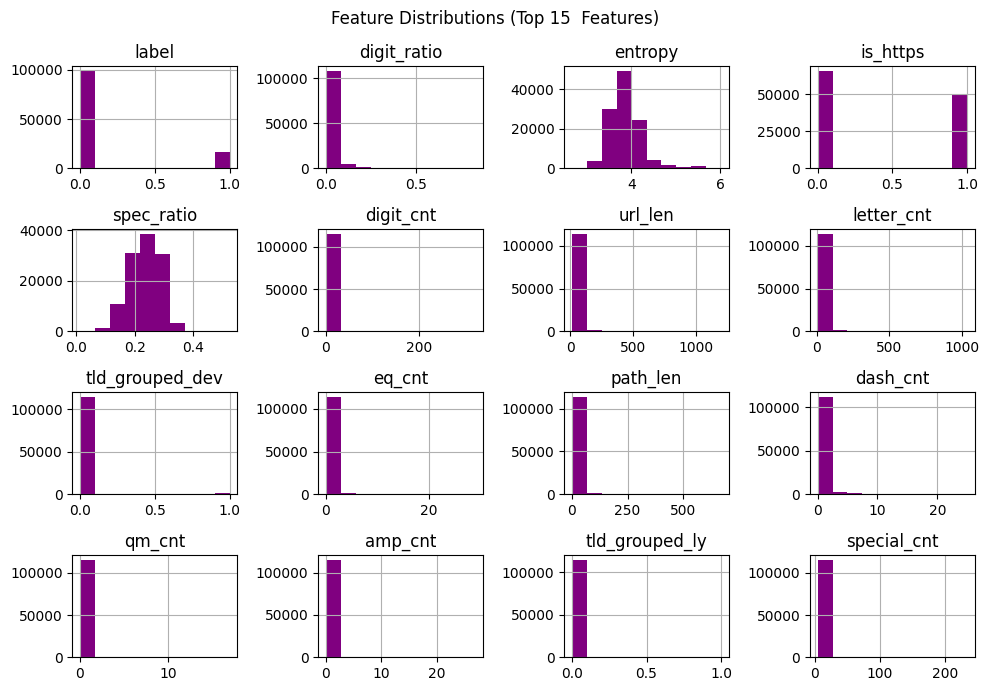

In [28]:
# Plotting the distribution of each feature
data[top_features].hist(figsize=(10, 7), color = "purple")
plt.suptitle("Feature Distributions (Top 15  Features)")
plt.tight_layout()
plt.show()

**Observation:** To keep the visualizations interpretable, I am reusing the top features from the correlation heatmap, as their correlations hinted at their importance. The feature distributions show, that most features are heavily skewed or have high outliers. For some of them, different values are hardly visible because the distributions are highly compressed due to high values, this can for example be seen in url_len and letter_cnt. Furthermore, most features lean towards the 0 value, especially the count features like special_cnt, which means that most urls are fairly simple with some outliers. These observations mean that further thought and processing need to be put into the data, like for example scaling or transformations like log transformation, before applying deep learning algorithms. Furthermore, this points to looking into outliers, which is my the next step will be plotting boxplots.

## Visualization 3 - Boxplots

Boxplots of the previously selected features

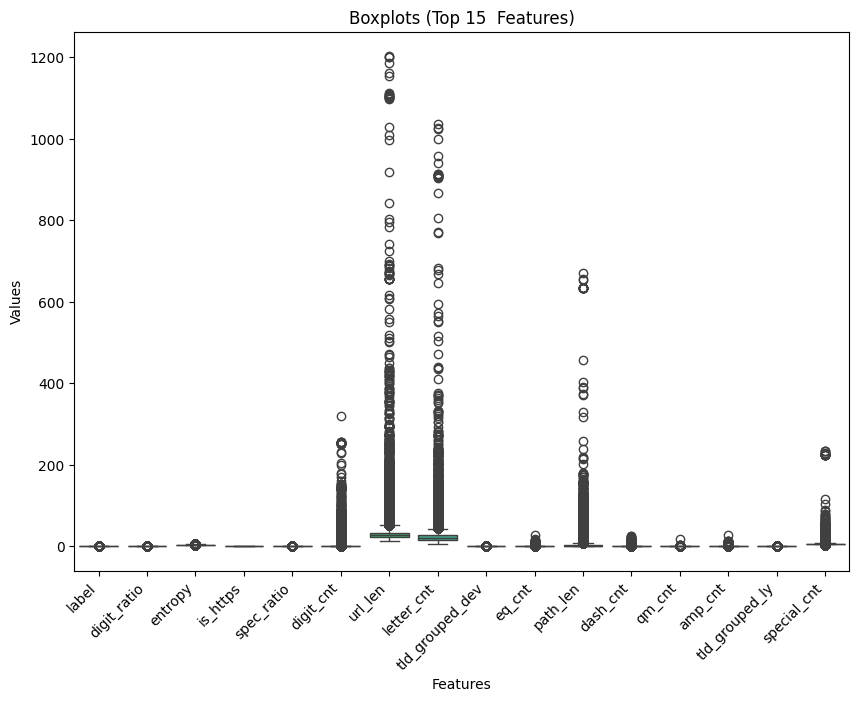

In [29]:
# Box plots
plt.figure(figsize=(10, 7))
sns.boxplot(data=data[top_features])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Values")
plt.title("Boxplots (Top 15  Features)")
plt.show()

**Observation:** To keep in line with the first two visualizations, I am reusing the top_features, as to make the boxplots interpretable. As suggested in the feature distributions, some features have very high outliers, for example teh url_len, path_len, letter_cnt and digit_cnt. The connection between the four make sense, as a longer url could very possibly have a longer path. Furthermore, it needs to consist of something, possibly digits and letters. I will not remove those outliers, as they could very well be an indication for phishing, as extreme values could be meaningful variation instead of noise. Furthermore, these features all have a positive correlation with the target label, meaning that a higher  value, is associated with a higher likelyhood of a url ibeing phishing, which can be deduced from the correlation heatmap.
Additionally, the boxplots show the same as the feature distributions, that most values are towards zero with just some features having long tails. Therefore, most urls seem to be fairly simple, with some complexer extremes in the mix.

# Task 5 - Evaluation and Baseline

Choosing two evaluation metrics and two baselines 

## 1. Evaluation metrics 

**Balanced Accuracy:**\
Chosen because:
* class imbalance in the label (98634 safe to 16583 phishing) 
* --> avoid always predicting not phishing and having high accuracy even though performance is bad
* Model should perform well for both classes, as phishing needs to be detected but users should not regularily be blocked from safe sites 

**Recall:**\
Chosen because:
* Security --> more important to detect phishing 
* Rather minimize false negative than false positive
* Trade-off: rather safer from phishing but blocked from a few safe sites 

--> In total, a combination of both metrics is important. For security reasons, the recall is chosen so the risk of not detecting phishing is minimized. At the same time, the model is only useful, if not too many safe sites are labeled as phishing, which is why balanced accuracy was chosen to complement the recall and help evaluate the overall performance of the model, considering both classes equally.

## 2. Baselines

As a reference for baselines I have used https://medium.com/@mohsenmostafa833/baselines-3f702e143e49 

In [30]:
# split label from features 
final_data = data.drop(columns="label")
target = data.loc[:, ["label"]]

# train test split for baselines and all following experiments
X_train_full, X_test, y_train_full, y_test = train_test_split(final_data, target, test_size=0.4, shuffle=True, random_state=1, stratify=target)

**Majority class baseline**\
Chosen because:
* Will show high accuracy as there is an imbalance
* Commonly used for binary classification
* Stronger than random guessing --> want to outperform stronger baseline 
* Demonstrates why chosen metrics are useful to evalute more deeply --> very badly for recall
* Simple but telling 

In [31]:
# Largest Class Baseline
dc = DummyClassifier(strategy="most_frequent") # choose largest class for the baseline classifier
dc.fit(X_train_full, y_train_full) # fit baseline model; does not acutally learn --> no trained model
y_pred_dc = dc.predict(X_test) # predict on test set
accuracy_dummy = accuracy_score(y_test, y_pred_dc)
bal_accuracy_dummy = balanced_accuracy_score(y_test, y_pred_dc)
recall_dummy = recall_score(y_test, y_pred_dc)
print(f"Accuracy: {accuracy_dummy}, Balanced Accuracy: {bal_accuracy_dummy}, Recall: {recall_dummy}")

Accuracy: 0.8560765508711784, Balanced Accuracy: 0.5, Recall: 0.0


**Observation:** The accuracy is quite high with almost 86%, but the balanced accuracy is only 50% and the recall 0, which is especially bad. Therefore, this baseline shows that accuracy is not everything and balanced accuracy and recall need to evaluated.

**Rule Based heuristic based on url_len**\
Chosen because:
* no trained model 
* very simple 
* url_len is intuitive indicator for phishing and has correlation with target
* rules can be deduced from EDA
* might achieve higher scores for chosen metrics on imbalanced classes
* --> complements majority class baseline
* but only depending on one feature --> does not depict relationships --> expected to be outperformed with deep learning

Median as threshold:
* simple without added complexity 
* robust to extreme values (important, as data is skewed)
* results show that median is sufficient and the threshold does not need to be fine-tuned

In [32]:
threshold = X_train_full["url_len"].median()
y_pred_rule = (X_test["url_len"] > threshold).astype(int)
accuracy_rule = accuracy_score(y_test, y_pred_rule)
bal_accuracy_rule = balanced_accuracy_score(y_test, y_pred_rule)
recall_rule = recall_score(y_test, y_pred_rule)
print(f"Accuracy: {accuracy_rule}, Balanced Accuracy: {bal_accuracy_rule}, Recall: {recall_rule}")

Accuracy: 0.6209777160587584, Balanced Accuracy: 0.6971082839938996, Recall: 0.8040102517714458


**Observation:** The accuracy is moderate with about 62%. The balanced accuracy is 70%, which is decent for a baseline, and the recall is at 80% which is already fairly good. The baseline already catches a lot of phishing, but somewhat at the cost more false positives (labeling safe urls as phishing), as the accuracy is not as high. Therefore, this baseline complements the majority class baseline well, as it has a decent balanced accuracy and a good recall, while the majority class baseline has a high accuracy. Therefore, if a complex model in my deep learning experiments outperforms these baselines, that is an indication that the model might be useful.

# Task 6 - Deep Learning Architecture

In the following, two deep learning architectures will be built and explained

## Architecture 1

In [33]:
# Dropout architecture with ReLU activation function 
class MLPDropout(nn.Module):

    def __init__(self, input_size):
        super(MLPDropout, self).__init__()
        self.hidden_1 = nn.Linear(input_size, 128)
        self.hidden_2 = nn.Linear(128, 64)
        self.hidden_3 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        out1 = self.activation(self.hidden_1(x))
        out1 = self.dropout(out1)
        out2 = self.activation(self.hidden_2(out1))
        out2 = self.dropout(out2)
        out3 = self.activation(self.hidden_3(out2))
        return self.output(out3)

**Explanation:**\
ReLU activation function:
* Introduces non-linearity --> model can learn complex relationships --> chosen because the higher probability of complex relationships needed for the classification was derived from the EDA 
* Sigmoid is staple for binary classification, but ReLU helps mitiage vanishing gradient problem --> improved efficiency

Dropout layers: 
* Randompy dactivates neurons --> used to mitigate overfitting 
* Better generalization

This architecture was chosen to mitigate problems like overfitting or vanishing gradients while also being able to learn complex relationships between the various features, as there are quite a lot of features with 72. 

## Architecture 2

In [34]:
# BatchNorm architecture with LeakyReLU activation function 
class MLPBatchNorm(nn.Module):

    def __init__(self, input_size):
        super(MLPBatchNorm, self).__init__()
        self.hidden_1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.hidden_2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.hidden_3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.output = nn.Linear(32, 1)
        self.activation = nn.LeakyReLU(0.01)

    def forward(self, x):
        out1 = self.hidden_1(x)
        out1 = self.bn1(out1)
        out1 = self.activation(out1)
        out2 = self.hidden_2(out1)
        out2 = self.bn2(out2)
        out2 = self.activation(out2)
        out3 = self.hidden_3(out2)
        out3 = self.bn3(out3)
        out3 = self.activation(out3)
        return self.output(out3)

**Explanation:**\
LeakyReLU activation function:
* Introduces non linearity --> same as ReLU
* In the negative, LeakyReLU has small values for gradient --> less risk for dead neurons 

Batch Normalization:
* Used to stabilize training 
* Normalization of layer outputs --> gradient descent convergence happens more efficiently 


**Overall:**
In both cases, the number of neurons starts with 128 and ends with 1, as one label is expected in the output. Furthermore, 128 was chosen as the starting point, so the model has the capacity to learn complex relationships between the 72 features before gradually compressing the information until one label is the outcome. Furthermore, for deep learning standards, the dataset of 115,000 instances is not very big, meaning that for a starting point the network size is sufficient and it probably does not need to be bigger. Especially as a large number of parameters and hyperparameters has a higher risk of overfitting, which I want to avoid.

# Task 7 - Experiments

Preparing and running deep learning experiments

## 1. Prepare the data

Splitting, scaling, fit and transform, as well as creating tensors and data loaders

In [35]:
# split validation from train set
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, shuffle=True, random_state=1)

In [36]:
# Scaling
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()


In [37]:
# Fit and transform 
x_scaler.fit(X_train_full)
X_train_sc = x_scaler.transform(X_train)
X_val_sc=x_scaler.transform(X_val)
X_test_sc = x_scaler.transform(X_test)

In [38]:
y_scaler.fit(y_train_full)
y_train_sc=y_scaler.transform(y_train)
y_val_sc=y_scaler.transform(y_val)
y_test_sc=y_scaler.transform(y_test)

**Explanation:** I did not scale for the baselines, as the majority class baseline is not dependent on the values as it always predicts the majority class. And the rule based heuristic uses a median as threshold, which would just change accordingly when scaling the data. Furthermore, it is slightly less easy to interpret after scaling, which is why I found using the raw values for the baseline more intuitive.

In [39]:
# create tensors
X_train_tensor=torch.Tensor(X_train_sc)
X_val_tensor=torch.Tensor(X_val_sc)
X_test_tensor=torch.Tensor(X_test_sc)
y_train_tensor=torch.Tensor(y_train_sc)
y_val_tensor=torch.Tensor(y_val_sc)
y_test_tensor=torch.Tensor(y_test_sc)

In [40]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# shuffle data to get different order in each epoch --> mitigate overfitting
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True) 
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

## 2. Set hyperparameters

Learning rate, schedulers, number of epochs, criterion

In [41]:
learning_rates = [0.001, 0.0001]

**Explanation**: \
0.001:
* standard default in deep learning experiments --> proven strategy 
* Especially default for Adam Optimizer
* moderate value --> neither too high (divergence) or too low (inefficient model)

0.0001:
* smaller learning rate
* less reactive to outliers --> as seen in EDA, dataset has quite a few


In [42]:
# scheduler list to loop over
scheduler_types = [
    "none",
    "step",
    "plateau",
    "cosine"
]

In [43]:
# get the scheduler with parameters according to value in the list 
def get_scheduler(optimizer, scheduler_type, epochs):
    if scheduler_type == "none":
        return None
    
    if scheduler_type == "step":
        return torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=10
        )
    
    if scheduler_type == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            patience=3
        )
    
    if scheduler_type == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs
        )

**Explanation:**\
Four different schedulers as described in the task.\
I None --> no scheduler 

II Step Decay --> a fix learning rate decay in fix intervals of epoch\
Parameters:
Step Size: Chosen 10, moderate, not too high as to not miss too much 

III Plateau --> reduces learning rate when chosen metric does not improve for a chosen number of epochs \
Parameters:
Patience: Number of allowed epochs without improvement; I have chosen 50 epochs so I am keeping this low as well

IV Cosine --> cosine annealing scheduler reduces learning rate gradually from maximum to minimum\
Parameters:
T_max: epochs --> maximum number of iterations, want minimum in the last epoch, therefore, number of epochs

In [44]:
# architectures list to loop over 
architectures = {
    "MLPDropout": MLPDropout,
    "MLPBatchNorm": MLPBatchNorm
}

In [45]:
# set number of epochs
epochs = 50 

**Explanation:** I am using fixed number of 50 epochs, as the architectures are fairly simple and the dataset is not too big. Furthermore, I am not using an early stopping mechanism to automatically stop at the point that the network has converged. Therefore, I am using 50 epochs because not want to use a lot of time and computational resources if that is not neccessary but also leave enough time for the network to learn the relationships between the features. Furthermore, 50 epochs is enough to later analyze the loss and chosen metrics and compare them between architectures. 

In [46]:
criterion = nn.BCEWithLogitsLoss()

**Explanation:** I have chosen BCE with Logits Loss because it combines the BCE loss with a Sigmoid Layer, which is both widely used for binary classification, which is the core of my task. Because I am using this loss function, I have not used a Sigmoid activation function in my architectures. Sigmoid is used for binary classification, because it transforms the output into a probalility which then leads to the model being able to use that probability to predict the class. BCE then evaluates how close the probability that was predicted is to the target label. 

Sources I used for determining the Loss function and the explanations:
* https://www.codecademy.com/learn/neural-networks-bamlm/modules/py-torch-for-classification-bamlm-2024/cheatsheet
* https://docs.pytorch.org/docs/2.11/generated/torch.nn.BCEWithLogitsLoss.html 

## 3. Train Model Function 

Create the training and validation function to later call when training the model

In [47]:
# Train function ´
def train_model(model, epochs, train_loader, val_loader,
                optimizer, criterion, scheduler=None, scheduler_type="none"):

    best_model = copy.deepcopy(model.state_dict()) # to save the best model
    best_val_bal_acc = -float("inf")
    best_epoch = 0

    # history of important metrics
    history = {
        "train_loss": [],
        "train_balanced_accuracy": [],
        "train_recall": [],
        "val_loss": [],
        "val_balanced_accuracy": [],
        "val_recall": [],
        "learning_rate": []
    }

    # loop for one epoch, repeated for number of epochs 
    for epoch in range(epochs):

        model.train()
        train_loss = 0.0

        all_train_targets = []
        all_train_preds = []
        
        # training loop 
        for X_batch, y_batch in train_loader:

            y_train_pred = model(X_batch)
            train_predictions = (y_train_pred >= 0).int()

            all_train_targets.append(y_batch.int())
            all_train_preds.append(train_predictions)

            loss_train = criterion(y_train_pred, y_batch)

            optimizer.zero_grad()
            loss_train.backward()
            optimizer.step()

            train_loss += loss_train.item() * X_batch.size(0)
            

        train_loss = train_loss / len(train_loader.dataset)

        all_train_targets = torch.cat(all_train_targets).cpu().numpy()
        all_train_preds = torch.cat(all_train_preds).cpu().numpy()

        train_bal_acc = balanced_accuracy_score(all_train_targets, all_train_preds)
        train_recall = recall_score(all_train_targets, all_train_preds)

        # call evaluation model; dropout etc. deactivated 
        model.eval()
        val_loss = 0.0

        all_val_targets = []
        all_val_preds = []

        # validation loop
        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                y_val_pred = model(X_batch)

                loss_val = criterion(y_val_pred, y_batch)
                val_loss += loss_val.item() * X_batch.size(0)

                predictions = (y_val_pred >= 0).int()

                all_val_targets.append(y_batch.int())
                all_val_preds.append(predictions)

        val_loss = val_loss / len(val_loader.dataset)

        all_val_targets = torch.cat(all_val_targets).cpu().numpy()
        all_val_preds = torch.cat(all_val_preds).cpu().numpy()

        val_bal_acc = balanced_accuracy_score(all_val_targets, all_val_preds)
        val_recall = recall_score(all_val_targets, all_val_preds)

        if scheduler is not None: # because no step if there is no scheduler
            # plateau needs val loss, so it needs to be handled differently
            if scheduler_type == "plateau": 
                scheduler.step(val_loss)
            # other two schedulers
            else:
                scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_balanced_accuracy"].append(train_bal_acc)
        history["train_recall"].append(train_recall)
        history["val_loss"].append(val_loss)
        history["val_balanced_accuracy"].append(val_bal_acc)
        history["val_recall"].append(val_recall)
        history["learning_rate"].append(current_lr)

        if val_bal_acc > best_val_bal_acc:
            best_val_bal_acc = val_bal_acc
            best_model = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        print( # print some data to observe during training
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val BA: {val_bal_acc:.4f} | "
            f"Val Recall: {val_recall:.4f} | "
            f"LR: {current_lr:.6f}"
        )

    print(f"Best Validation Epoch: {best_epoch + 1}")

    model.load_state_dict(best_model)

    return model, history, best_epoch, best_val_bal_acc

**Explanation:** The above function is the training of the model. 
The data is loaded using the predefined data loaders, to have a different order of data for each epoch. In the history, important values like the training and validation loss, as well as the balanced accuracy and recall of the validation set are being tracked. Furthermore, the predefined schedulers are loaded. For the given scheduler and learning rate, the function loops through the number of epochs that has been set above. Additionally, a deepcopy of the parameters of the best epoch is made.

## 4. Evaluation Function 

Use the test data to test the models with this function 

In [48]:
# Evaluation function
def evaluate_model(model, test_loader, criterion):

    # use evaluation model 
    model.eval()
    test_loss = 0.0

    all_test_targets = []
    all_test_preds = []

    with torch.no_grad():

         # test loop
        for X_batch, y_batch in test_loader:

            y_test_pred = model(X_batch)

            loss_test = criterion(y_test_pred, y_batch)
            test_loss += loss_test.item() * X_batch.size(0)

            predictions = (y_test_pred >= 0).int()

            all_test_targets.append(y_batch.int())
            all_test_preds.append(predictions)

    test_loss = test_loss / len(test_loader.dataset)

    all_test_targets = torch.cat(all_test_targets).cpu().numpy()
    all_test_preds = torch.cat(all_test_preds).cpu().numpy()

    test_bal_acc = balanced_accuracy_score(all_test_targets, all_test_preds)
    test_recall = recall_score(all_test_targets, all_test_preds)

    return test_loss, test_bal_acc, test_recall

**Explanation:** The above function is for evaluation the model. This is done on the test set, which the models have not seen during the training phase (as opposed to the validation set). The function returns the loss, balanced accuracy and recall on the test set.

## 5. Training

Call the above functions, train the models and evalute them

In [49]:
results = [] # empty to save results
best_epoch_results = [] # for best epochs table 
histories = {} # empty dict to save history 
input_size = X_train_tensor.shape[1] # number of features
trained_models = {} # to extract chosen model for confusion matrix later 

# loop over architectures 
for architecture_name, architecture_class in architectures.items():

    # loop over learnin rates
    for lr in learning_rates:

        # loop over schedulers 
        for type in scheduler_types:

            print(f"\nRunning: {architecture_name}, lr={lr}, scheduler={type}")

            model = architecture_class(input_size)

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=lr
            )

            # call scheduler function
            scheduler = get_scheduler(
                optimizer=optimizer,
                scheduler_type=type,
                epochs=epochs
            )
            # call train function 
            model, history, best_epoch, best_val_bal_acc = train_model(
                model=model,
                epochs=epochs,
                train_loader=train_loader,
                val_loader=val_loader,
                optimizer=optimizer,
                criterion=criterion,
                scheduler=scheduler,
                scheduler_type=type
            )
            # call evaluation function
            test_loss, test_bal_acc, test_recall = evaluate_model(
                model=model,
                test_loader=test_loader,
                criterion=criterion
            )

            # save results etc. for further analysis

            experiment_name = f"{architecture_name}_lr{lr}_{type}"

            histories[experiment_name] = history

            trained_models[experiment_name] = copy.deepcopy(model) # for extracting chosen model later

            results.append({
                "architecture": architecture_name,
                "learning_rate": lr,
                "scheduler": type,
                "test_loss": test_loss,
                "test_balanced_accuracy": test_bal_acc,
                "test_recall": test_recall
            })
            best_epoch_results.append({
                "architecture": architecture_name,
                "learning_rate": lr,
                "scheduler": type,
                "best_epoch": best_epoch + 1,
                "best_val_bal_acc": best_val_bal_acc
            })


Running: MLPDropout, lr=0.001, scheduler=none
Epoch 001 | Train Loss: 0.3073 | Val Loss: 0.1257 | Val BA: 0.8536 | Val Recall: 0.7208 | LR: 0.001000
Epoch 002 | Train Loss: 0.1180 | Val Loss: 0.1072 | Val BA: 0.9250 | Val Recall: 0.8764 | LR: 0.001000
Epoch 003 | Train Loss: 0.1019 | Val Loss: 0.0941 | Val BA: 0.9109 | Val Recall: 0.8369 | LR: 0.001000
Epoch 004 | Train Loss: 0.0948 | Val Loss: 0.0952 | Val BA: 0.9372 | Val Recall: 0.8994 | LR: 0.001000
Epoch 005 | Train Loss: 0.0895 | Val Loss: 0.0835 | Val BA: 0.9194 | Val Recall: 0.8501 | LR: 0.001000
Epoch 006 | Train Loss: 0.0841 | Val Loss: 0.0842 | Val BA: 0.9068 | Val Recall: 0.8204 | LR: 0.001000
Epoch 007 | Train Loss: 0.0797 | Val Loss: 0.0768 | Val BA: 0.9361 | Val Recall: 0.8876 | LR: 0.001000
Epoch 008 | Train Loss: 0.0766 | Val Loss: 0.0737 | Val BA: 0.9316 | Val Recall: 0.8734 | LR: 0.001000
Epoch 009 | Train Loss: 0.0740 | Val Loss: 0.0701 | Val BA: 0.9489 | Val Recall: 0.9115 | LR: 0.001000
Epoch 010 | Train Loss: 0.

**Explanation:** The above code calls the training and evaluation functions and loops through all the combinations of schedulers and learning rates. During the training, the output shows the development of important metrics like loss, balanced accuracy and recall.

# Task 8 - Discussion

## Results from Training

Presentation of the final test results for all model configurations

In [50]:
results_df = pd.DataFrame(results)

# add baselines 
results_df.loc[len(results_df)] = {
    "architecture": "DummyClassifier",
    "learning_rate": "-",
    "scheduler": "-",
    "test_loss": "-",
    "test_balanced_accuracy": bal_accuracy_dummy,
    "test_recall": recall_dummy
}

results_df.loc[len(results_df)] = {
    "architecture": "URLLengthRule",
    "learning_rate": "-",
    "scheduler": "-",
    "test_loss": "-",
    "test_balanced_accuracy": bal_accuracy_rule,
    "test_recall": recall_rule
}
 
# rank by balanced accuracy to see best models at first glance
results_df.sort_values(
    by="test_balanced_accuracy",
    ascending=False
).reset_index(drop=True)

,architecture,learning_rate,scheduler,test_loss,test_balanced_accuracy,test_recall
0,MLPBatchNorm,0.001,plateau,0.051331,0.968356,0.947686
1,MLPBatchNorm,0.001,cosine,0.051135,0.967946,0.945575
2,MLPBatchNorm,0.001,none,0.056379,0.966717,0.948590
3,MLPBatchNorm,0.001,step,0.050886,0.966175,0.942108
4,MLPDropout,0.001,none,0.055743,0.963724,0.937434
5,MLPBatchNorm,0.0001,none,0.054913,0.963370,0.937283
6,MLPBatchNorm,0.0001,plateau,0.055164,0.963269,0.937133
7,MLPDropout,0.001,plateau,0.054768,0.960878,0.930348
8,MLPBatchNorm,0.0001,cosine,0.0579,0.960629,0.932157
9,MLPDropout,0.001,cosine,0.055549,0.960338,0.929142


**Note on reruns:** Due to shuffling in the dataloader and other factors like Dropout layers, the absolute numbers in the results can fluctuate slightly between reruns

**Observation:**
* Generally good results, the models are able to distinguish phishing websites from benign ones fairly well across most combinations
* MLPBatchNorm with lr 0.001 performed best across all schedulers with test balanced accuracies around 0.97 and test recall around 0.95 --> indication for good generalization; especially cosine and plateau are very close 
* all schedulers for MLPBatchNorm with lr 0.001 are very close together --> all schedulers optimize well --> combination of MLPBatchNorm with lr 0.001 seems to generalize well in general
* The best balanced accuracy and recall are already fairly high, even though not all parameters have been optimized
* Need to check for overfitting, but test already uses the best epoch, not the last --> mitigates overfitting in later epochs --> but no early stopping, as training runs through all epochs 
* Test balanced accuracy is fairly strong across the results (between 0.97 and 0.89 and 0.97 and 0.91 without the last option'), while test recall drops more strongly (0.95 to 0.79) for the worse combinations --> weaker models struggle more with recall --> class imbalance could be the reason, they have problems generalizing for the minority class; this is something to note, as recall is important to see how well the model detects phishing
* MLP Dropout with lr of 0.0001 and step scheduler performs worst and with a considerably distance to the other options with a ba of 0.89 and recall of 0.79
* BatchNorm outperforms Dropout, when using the best epoch model and not the last
* No too general rule about the best scheduler can be made, it depends on the combination of scheduler, lr and architecture 
* For Dropout, the scheduler none produced the best results --> dropout introduces noise and deactivates neurons --> already regularizes training --> adding strong lr scheduling could be too much --> none leads to the best results --> this is not proven in the experiments, but rather an suggestion of a technical reason

**Comparison to baseline:**
* All combinations outperform both baselines on balanced accuracy, which indicates that the architectures generally generalize fairly well and can classify both classes 
* Almost all combinations outperform both baselines on the test recall --> models learnt both classes well --> indicator that there are more complicated relationships in the data and url length is not the only factor for phishing (which was the rule in the rule bases classifier)
* Only one method, MLPDropout with lr 0.0001 and step scheduler had a weaker recall than the rule bases baseline --> emphasizing that it is by far the weakest combination

## Best Epochs

Because I tested on the model with the parameters from the best epoch, I want to have a look at which epoch was the best for combinations. 

In [51]:
# present best epochs for each combination to see indication for wether longer training could be beneficial
best_epoch_df = pd.DataFrame(best_epoch_results)

best_epoch_df.sort_values(
    by="best_val_bal_acc",
    ascending=False
).reset_index(drop=True)

,architecture,learning_rate,scheduler,best_epoch,best_val_bal_acc
0,MLPBatchNorm,0.0010,cosine,36,0.970601
1,MLPBatchNorm,0.0010,none,19,0.970348
2,MLPBatchNorm,0.0010,plateau,21,0.969617
3,MLPBatchNorm,0.0010,step,41,0.967675
4,MLPDropout,0.0010,none,46,0.966409
5,MLPBatchNorm,0.0001,none,47,0.966100
6,MLPDropout,0.0010,plateau,45,0.964440
7,MLPBatchNorm,0.0001,plateau,45,0.963990
8,MLPBatchNorm,0.0001,cosine,39,0.963934
9,MLPDropout,0.0010,cosine,43,0.963680


**Observation:**
* Since dropout layers and shuffling dataloaders introduce some randomness, the best epoch does not always stay the same; in some reruns the best epoch was never the last, in some it was. Therefore, this will be inlcuded in the analysis
* For some combinations, the best epoch was the last one in some reruns --> might have benefitted from longer training, maybe the model has not fully converged yet but indication is low, as this does not happen in all reruns
* On the other hand, that could increase the risk of overfitting --> overfitting will be tested more closely in the next visualizations 
* Aside from two outliers (9, 18), all combinations had the best epoch between 30 and 50, meaning that training for at least 30 epochs is sensible
* No direct rule can be observed relating a high or low best epoch to either architecture or scheduler 
* Most of the combinations that had the best epoch in epoch 50 in some of the reruns have the lr 0.0001 --> lower lr means slower convergence --> probably would profit from more epochs --> could be the reason, combinations with lr 0.001 outperformed combinations with lr 0.0001

## Check for overfitting

I do not want to trust the test results alone, and will therefore check for indicators of overfitting, by comparing the train and validation loss, and afterwards the train and validation balanced accuracy

### 1. Comparing Train loss vs. Val loss

In [52]:
# function to plot the loss per epoch of training and validation
def plot_loss_comparison(histories, arch_name, lr):
    schedulers = ["none", "step", "plateau", "cosine"]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

    for ax, scheduler in zip(axes, schedulers):
        key = f"{arch_name}_lr{lr}_{scheduler}"
        history = histories[key]

        ax.plot(history["train_loss"], label="Train Loss")
        ax.plot(history["val_loss"], label="Validation Loss")

        ax.set_title(f"Scheduler: {scheduler}")
        ax.set_xlabel("Epoch")
        ax.grid(True)
        ax.legend()

    axes[0].set_ylabel("Loss")
    

    fig.suptitle(f"{arch_name} | LR={lr}", fontsize=14)
    plt.tight_layout()
    plt.show()

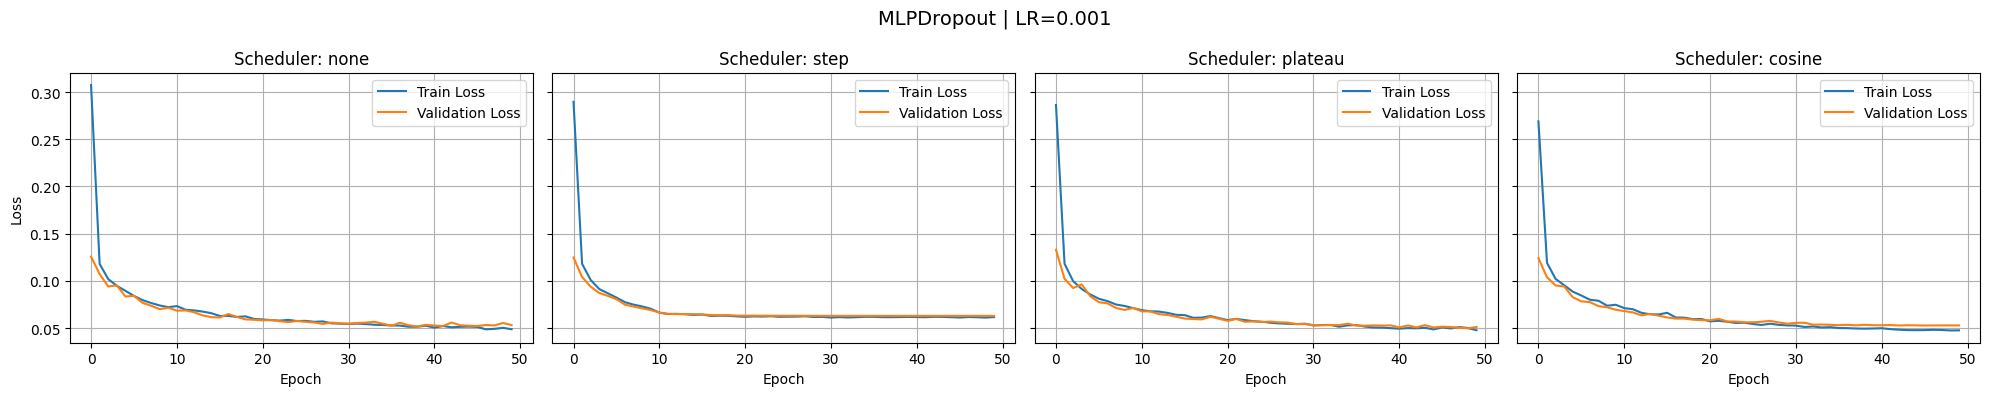

In [53]:
plot_loss_comparison(histories, "MLPDropout", 0.001)

**Observation:**
* Validation loss starts much lower for all schedulers --> possible reason is that dropout is only active during training --> validation process less regularized \
Side note: The dropout layer is deactivated for validation (with model.eval()), as that is common procedure in Deep Learning, as no randomness should be introduced in the validation process, and the model should use its full capacity (Source: https://www.geeksforgeeks.org/deep-learning/dropout-regularization-in-deep-learning/)
* schedulers look very similar 
* there is no to hardly any divergence in the higher epochs 
* both train and validation loss plateau, mostly starting between epoch 10 and 20 
* There is no indicator for overfitting in any scheduler configuration in combination with MLPDropout and lr 0.001

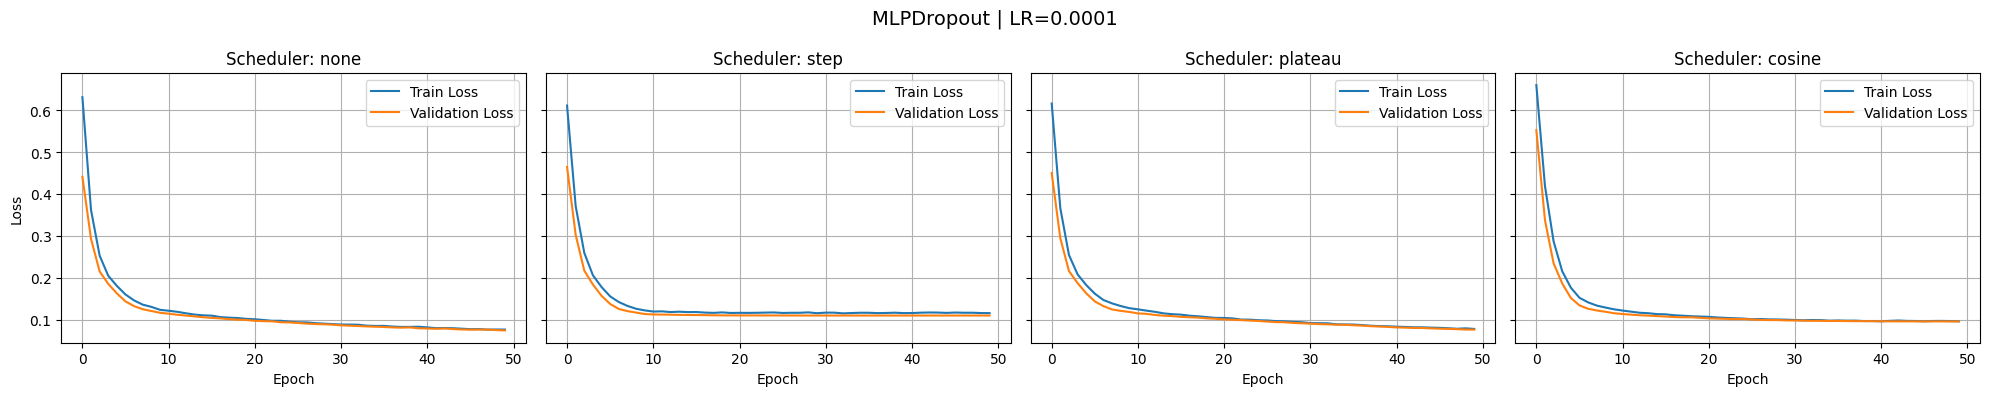

In [54]:
plot_loss_comparison(histories, "MLPDropout", 0.0001)

**Observation:**
* Very stable convergence behaviour, "text book like"
* no divergence --> no indication for overfitting 
* All schedulers start to plateau around 10 epochs 
* loss does not go down as much as for Dropout with lr 0.001 (0.1 vs 0.05) --> slower convergence due to lower lr
* plateau and none scheduler are still going down at the end --> both have their best epoch at 50 and 49 respectively --> plots support this observation --> more epochs might be beneficial

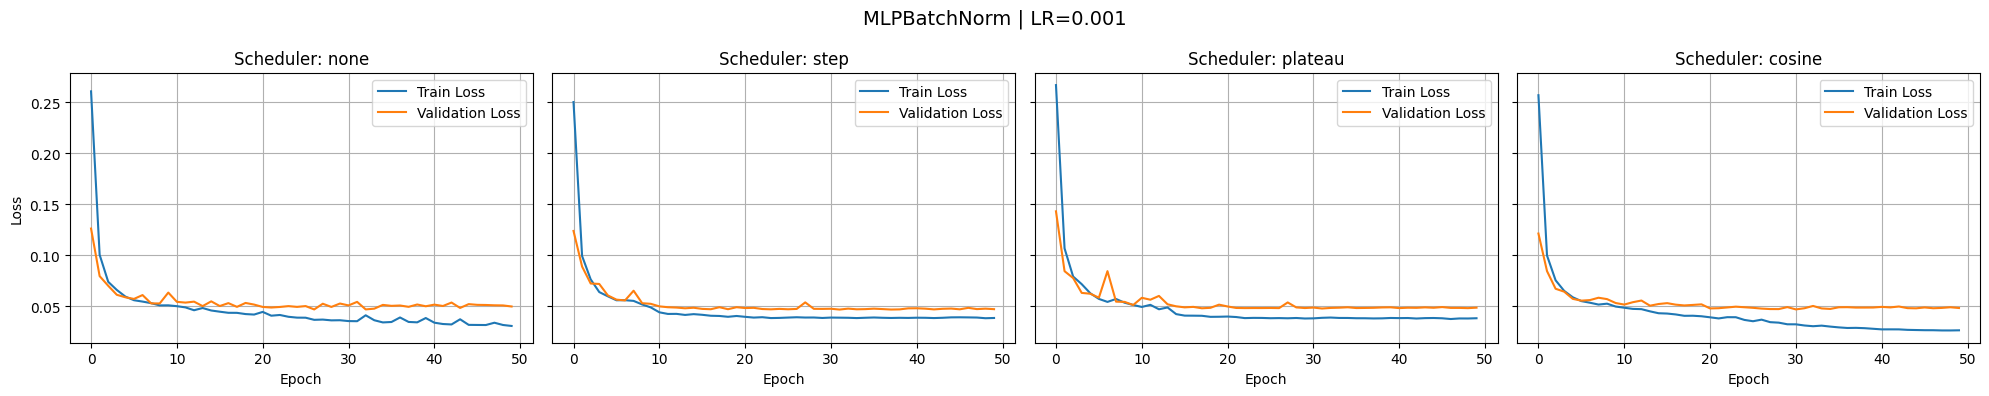

In [55]:
plot_loss_comparison(histories, "MLPBatchNorm", 0.001)

**Observation:** 
* For all four schedulers, training loss and validation loss start to diverge towards the end
* Strongest in none and cosine 
* Train loss is still decreaasing, while val loss is very steady
* Sign for the start of mild overfitting
* More epochs could lead to stronger overfitting
* Could be because no Dropout layer was used in the MLPBatchNorm architecture as compared to the MLPDropout architecture
* Val loss is still stable --> generalization still works
* higher lr --> loss is back down to 0.05 

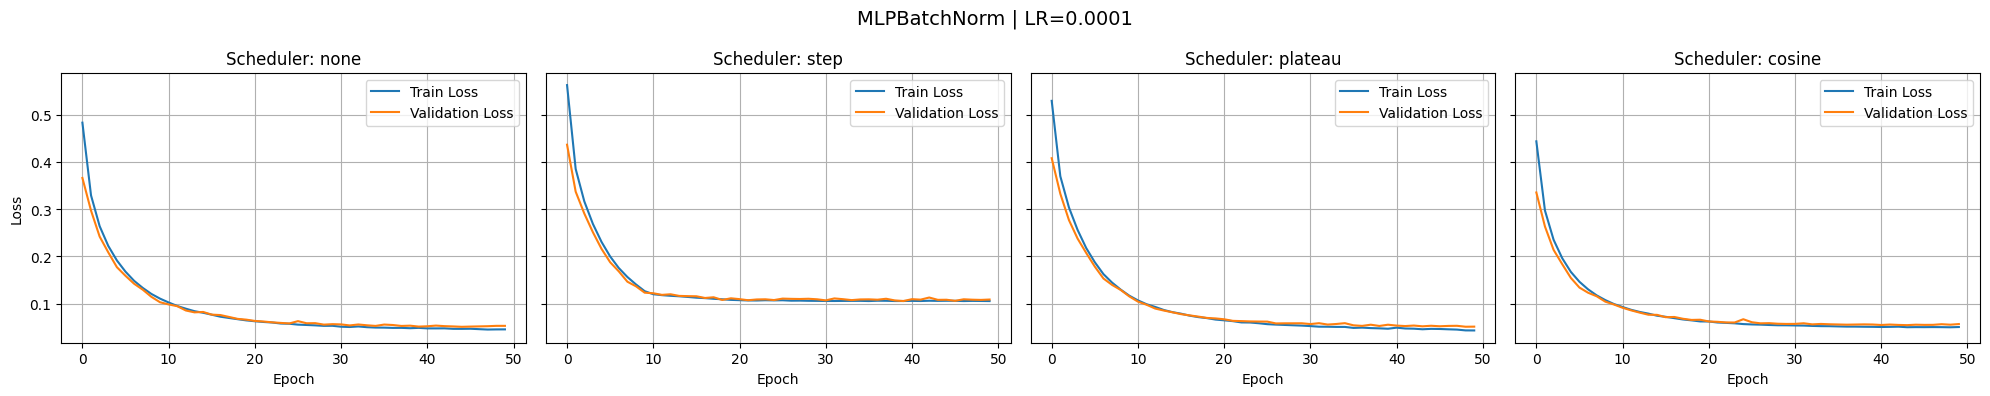

In [56]:
plot_loss_comparison(histories, "MLPBatchNorm", 0.0001)

**Observation:**
* Scheduler none, plateau and cosine are very similar 
* step does not go as low in the loss, with a plateau around 0.1, while the other schedulers go below 0.1 --> step scheduler with MLPBatchNorm and LR 0.0001 was the weakest BatchNorm combination 
* Again there is no divergence and no indication for overfitting 
* As compared to the Dropout architecture with lr 0.0001, the indication that more epochs could be beneficial is not as strong, with the curves already being flatter in the end, though in some reruns the best epoch for all except scheduler none is 50, so minor improvements might still be achieved with longer training

**Observation on Train loss vs Val loss in general**

There have been no strong signs of overfitting in the plots, with only MLPBatchNorm with a learning rate of 0.001 showing indications for the start of some overfitting, but within in the 50 epochs, the overfitting is still minor and not strong. Furthermore, the lr 0.0001 plots show a more stable loss due to slower convergence, as shown in the smoother curves, but they take longer to converge. Additionally, the loss for 0.001 is still fairly stable for all combinations. This suggests, that the models generalize and optimize well across combinations, which is also supported by the balanced accuracy and recall values in the results table.

### 2. Comparing Train Balanced Accuracy vs. Val Balanced Accuracy

In [57]:
# function to plot the balanced accuracy per epoch of training and validation
def plot_ba_comparison(histories, arch_name, lr):
    schedulers = ["none", "step", "plateau", "cosine"]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

    for ax, scheduler in zip(axes, schedulers):
        key = f"{arch_name}_lr{lr}_{scheduler}"
        history = histories[key]

        ax.plot(history["train_balanced_accuracy"], label="Train BA")
        ax.plot(history["val_balanced_accuracy"], label="Validation BA")

        ax.set_title(f"Scheduler: {scheduler}")
        ax.set_xlabel("Epoch")
        ax.grid(True)
        ax.legend()

    axes[0].set_ylabel("BA")
    

    fig.suptitle(f"{arch_name} | LR={lr}", fontsize=14)
    plt.tight_layout()
    plt.show()

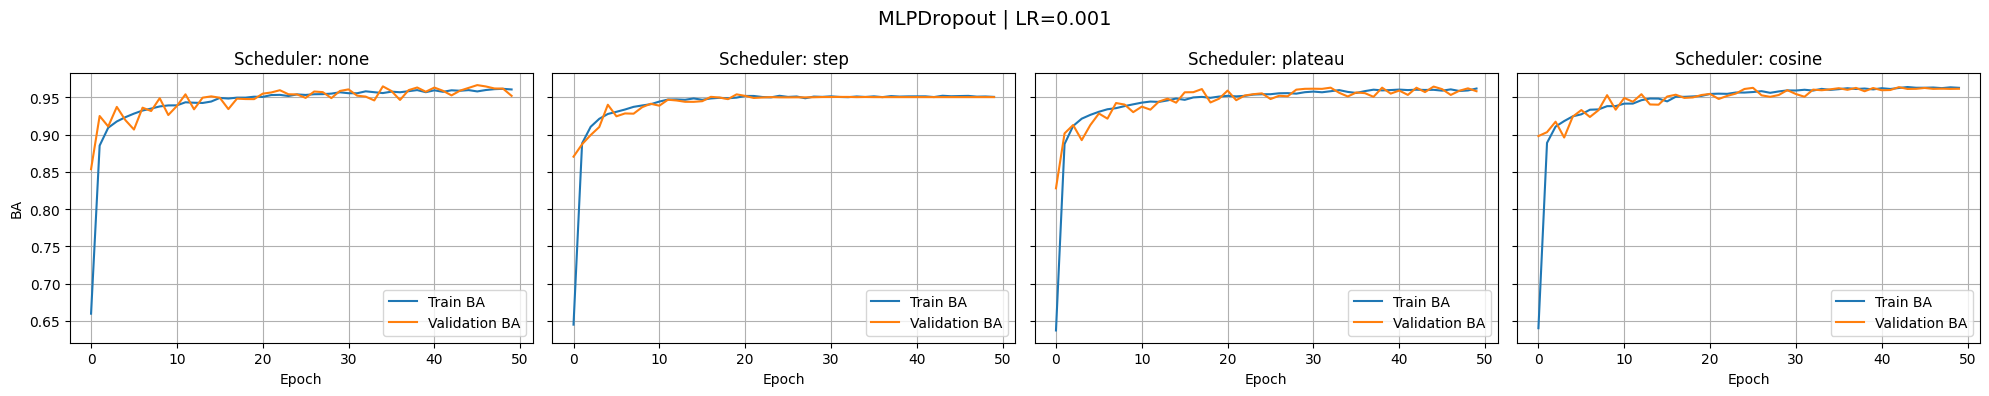

In [58]:
plot_ba_comparison(histories, "MLPDropout", 0.001)

**Observation:** 
* All schedulers look very similar --> previous observation that Dropout already regularizes and scheduler therefore does not have as much impact 
* Some instability in the valiation balanced accuracy, especially in the early epochs --> parameters are getting updated, model is not able to generalize yet in early epochs
* Step scheduler stabilizes the quickest for validation 
* All plateau about 0.95 BA and start around epoch 10 
* No clear divergence -> no indication for strong overfitting --> same observation as for the loss in this configuration

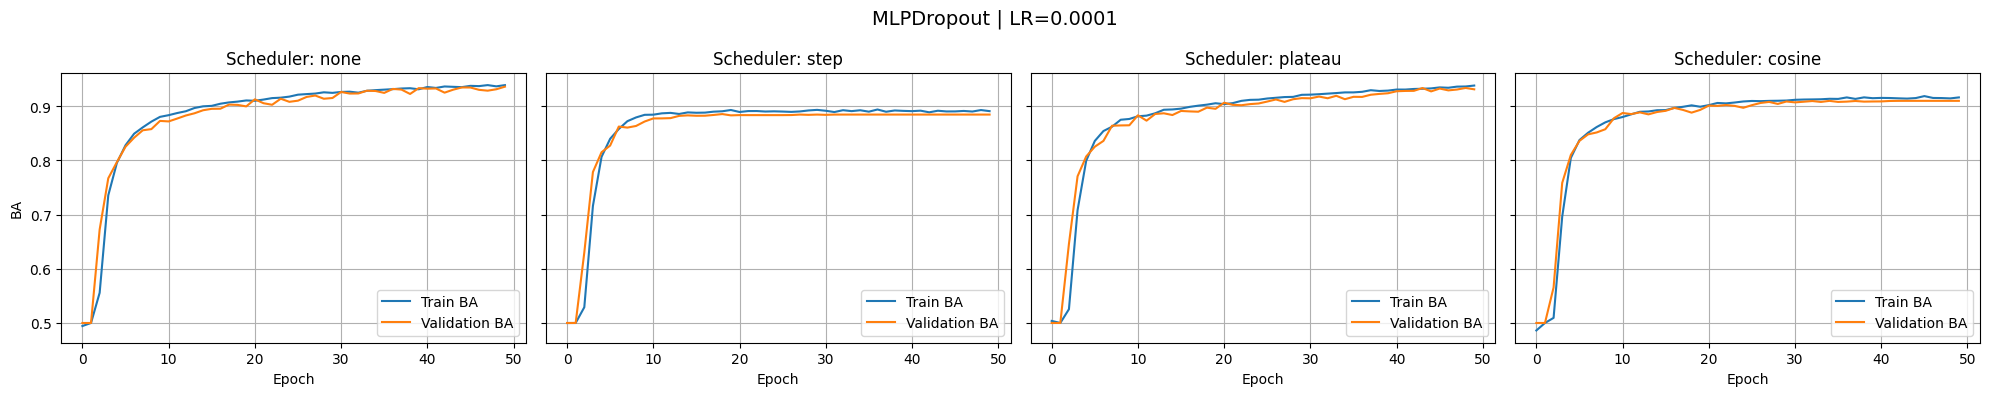

In [59]:
plot_ba_comparison(histories, "MLPDropout", 0.0001)

**Observation:**
* Step scheduler flattens very quickly after curve starts to plateau --> is the weakest combination, as seen in the results table, with the best epoch being epoch 18, suggesting that no improvement happens afterwards, which matches the very flat curve after that epoch 
* Curves are smoother, but that is likely due to the different scale
* BA is does not reach as high values as with lr 0.001, though the difference is small 
* No divergence --> no indication for overfitting 
* scheduler none and plateau are not as flat towards the end, both also have their best epoch being epoch 50 and 49 respectively, which are both a sign that the two combinations could profit from longer training, especially since the plots show no sign of overfitting --> same observation as for the loss 

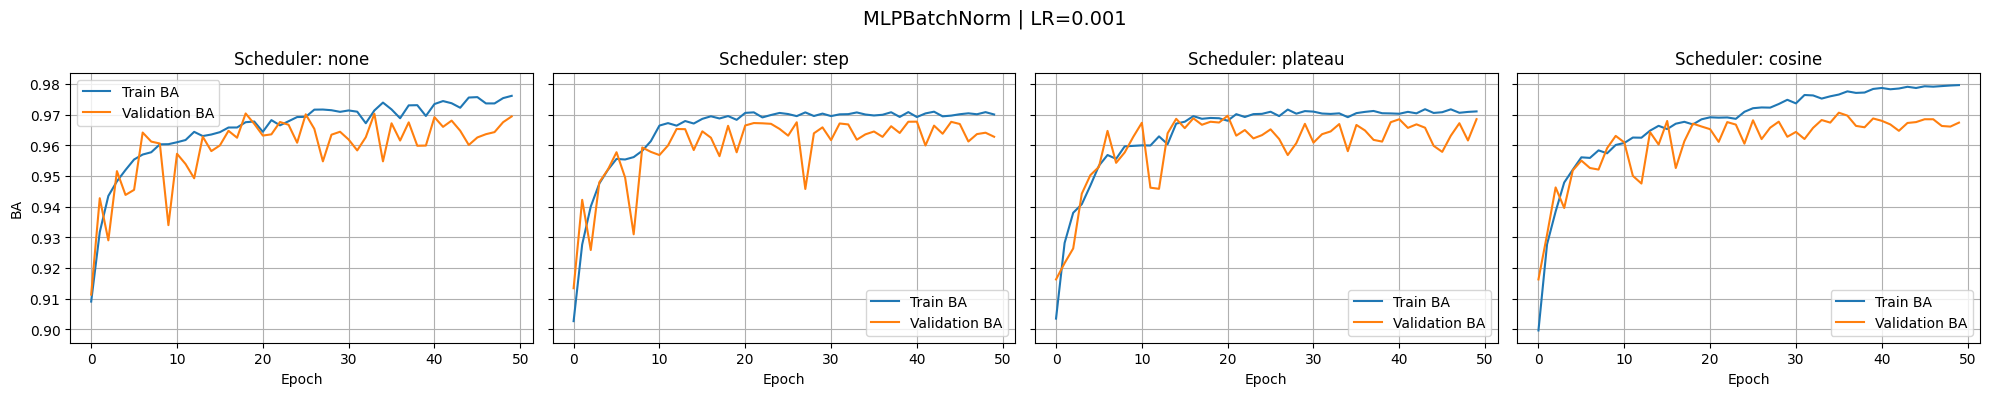

In [60]:
plot_ba_comparison(histories, "MLPBatchNorm", 0.001)

**Observation:**
* Training balanced accuracy increases fairly steadily, but less smooth as for the Dropout combinations
* Validation BA fluctuates and does not stabilize as much in later epochs --> struggles a bit to generalize 
* At the same time, highest test results for these combinations
* Gap between the curves increases --> divergence 
* IMPORTANT: The scale of these plots is different and has much smaller steps, therefore, fluctuations and divergence look stronger than they are, both instability and tendency to overfitting are still minor, which is why it is still possible that these options produced the best results
* Sign for some overfitting --> already observed diverging loss for the same model and lr combination
* Architecture does not have Dropout --> more prone to overfitting

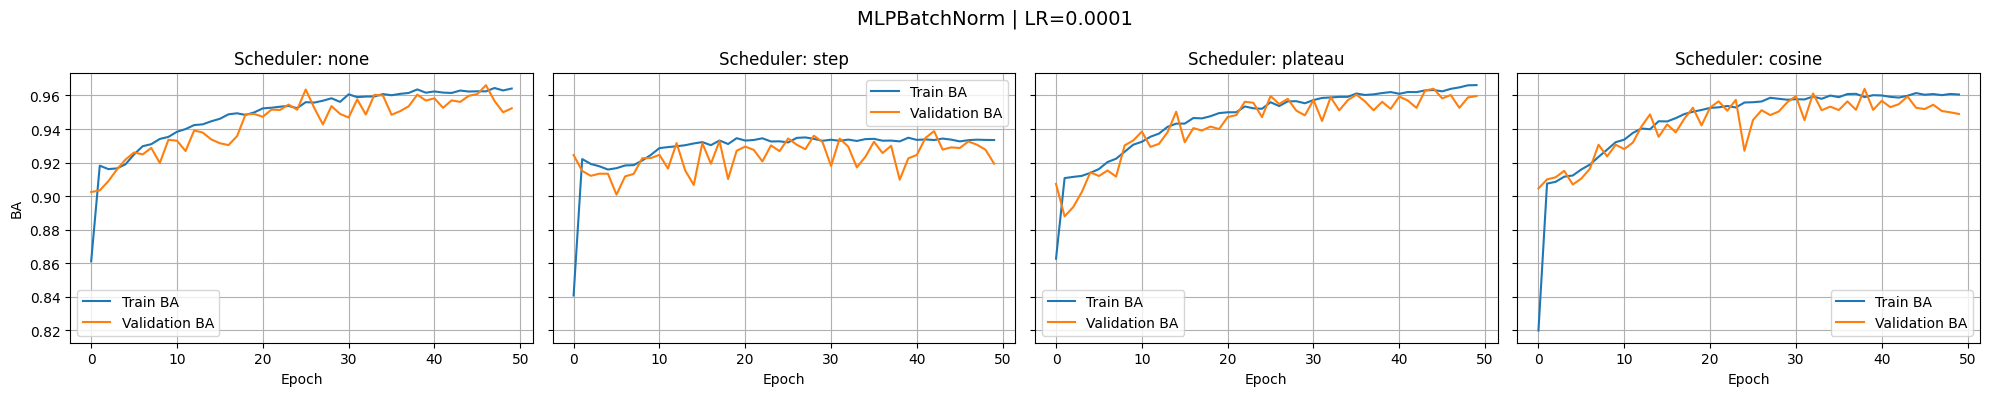

In [61]:
plot_ba_comparison(histories, "MLPBatchNorm", 0.0001)

**Observation**:
* Scheduler none and plateau do not really start to flatten yet, suggesting that they could possibly benefit from more epochs
* the best epochs in these cases could also happen because of small spikes due to fluctuation and the curve suggests that some more epochs might be beneficial --> only looking at the best epoch is not enough to determine how much training is the best 
* step starts to flatten early on, with convergence seemingly complete, suggesting more training would not help get the balaced accuracy up
* As for lr 0.001, the fluctuations are stronger compared to dropout, but the scale is also narrower again
* There is no clear divergence --> no sign of overfitting 
* lr 0.0001 showed lower results in ba compared to lr 0.001 for MLPBatchNorm, but as the curves suggest further training, and there are no signs of overfitting, as opposed to lr 0.001, these combinations (aside from scheduler step) also show high potential


**Observation on Train BA vs Val BA in general**
The observations in regards to overfitting align with those of the loss analysis, with only MLPBatchNorm with a lr of 0.001 showing indications for mild overfitting. BatchNorm combinations fluctuate more, but since the scales are narrower compared to Dropout Versions, the differences visually appear more drastic than they are in reality. Overall, the combinations all show that they generalize fairly well. In total, no concerning overfitting has been detected, neither in the loss nor the balanced accuracy.

## Comparing schedulers on Recall

Since recall was chosen as the other important metric, next to balanced accuracy, the recall performance of all combinations will be shown in the following. I did not add the recall train vs val plots, as that would make the findings about convergence, divergence and overfitting redundant with those of loss and balanced accuracy. Therefore, I have chosen to compare the schedulers more directly and only plot the recall for the validation.

In [62]:
# function to plot the recall for each combination, comparing the schedulers 
def plot_scheduler_comparison_recall(histories, architectures, learning_rates):

    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

    schedulers = ["none", "step", "plateau", "cosine"]

    plot_idx = 0

    for arch_name in architectures:
        for lr in learning_rates:

            ax = axes[plot_idx]

            for scheduler in schedulers:
                key = f"{arch_name}_lr{lr}_{scheduler}"
                history = histories[key]

                ax.plot(
                    history["val_recall"],
                    label=scheduler
                )

            ax.set_title(f"{arch_name} | LR={lr}")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Validation Recall")
            ax.grid(True)
            ax.legend()

            plot_idx += 1

    plt.tight_layout()
    plt.show()

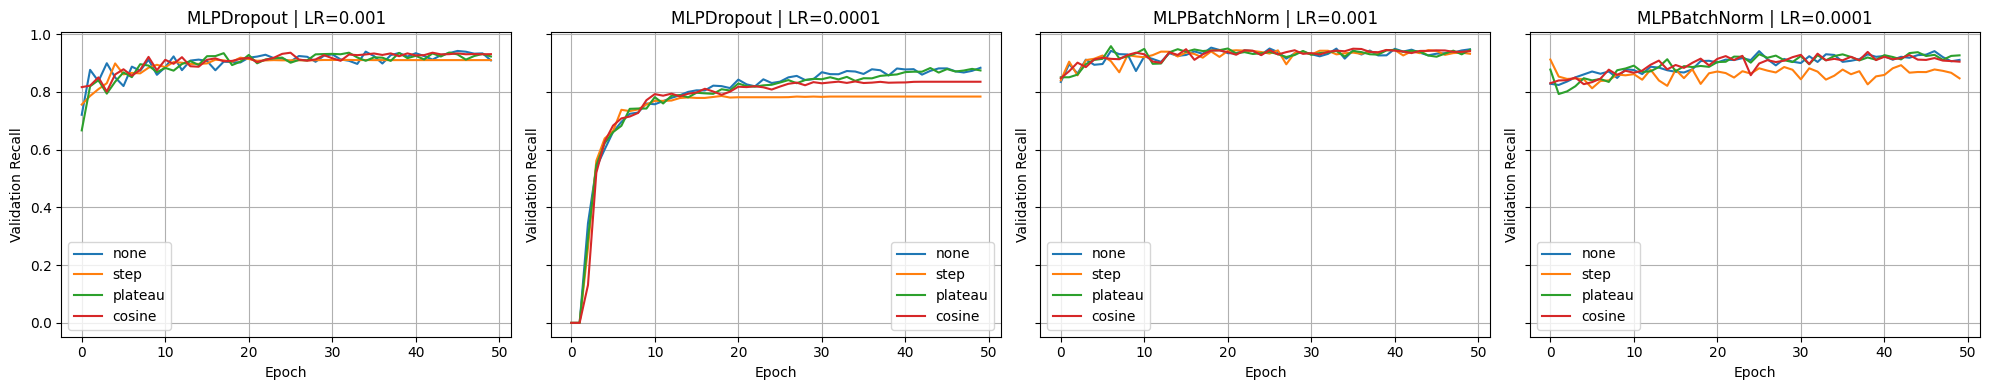

In [63]:
plot_scheduler_comparison_recall(
    histories,
    architectures=["MLPDropout", "MLPBatchNorm"],
    learning_rates=[0.001, 0.0001]
)

**Observation:**
* same scale for all plots to better compare fluctuations between architectures 
* All recall curves are fairly flat, except for MLPDropout with lr of 0.0001 which start much lower
* None of the plots show an indication that more epochs could improve the recall, as they are all fairly flat already and seem to converge early 
* BatchNorm versions start with higher recall --> also higher recall in total, produced the best results
* Aside from MLPBatchNorm with lr 0.0001, the step scheduer seems to be the weakest option --> possible reason: potentially steps too big for models to learn minority class
* Recall is fairly stable across all options, suggesting good generalization and handling of the minority class, aside from the minor problems of the step scheduler 

## Confusion Matrix

After checking for overfitting, I have decided that the best model is still the MLPBatchNorm with lr 0.001 and plateau scheduler, . In some reruns, cosine scheduler produced the best results, but it has a slight tendency towards overfitting, though it is only a mild start of overfitting. Furthermore, choosing the best epoch somewhat mitigates the overfitting. Additionally, the loss and balanced accuracy curves showed that the model was still stable and generalized well, meaning that the mild overfitting tendencies did not outweigh the strong overall performance of the model. Nevertheless, in other reruns the plateau scheduler was the leading combination and since both produced such similar results, but the plateau scheduler did not show any signs of overfitting, I am choosing that as the best model. Furthermore, some other options showed indications for improvement for longer training, but that is only a hypothetical and I want to choose the best model for the training done above. Especially, since the recall plots somewhat weaken the signs for improvement through longer training, as those curves are already fairly converged.

In [64]:
# select the chosen model and retrieve it
best_model_name = "MLPBatchNorm_lr0.001_plateau"
best_model = trained_models[best_model_name]

In [65]:
# run the best model on the test dataset 
best_model.eval()
all_targets = []
all_preds = []
with torch.no_grad():

    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        predictions = (y_pred >= 0).int()
        all_targets.append(y_batch.int())
        all_preds.append(predictions)

all_targets = torch.cat(all_targets).cpu().numpy()
all_preds = torch.cat(all_preds).cpu().numpy()

In [66]:
cm = confusion_matrix(all_targets, all_preds)

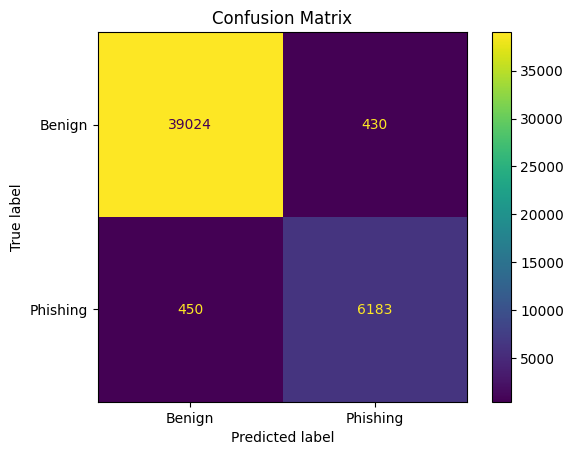

In [67]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Phishing"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

**Observation:**
* Diagonal has the most predictions --> strong classification 
* Only a small number of samples was misclassified; very similar number for both classes --> reflects high balanced accuracy score 
* False negatives (phishing labeled as benign) have a proportionally stronger impact on recall, as phishing is the minority class --> one explanation for lower recall value compared to balanced accuracy (recall 0.95 vs ba 0.97)

# Task 9 - Conclusions and Future Work

**1. Summarize and interpret the achieved results.**

* The achieved results are good across almost all combinations, outperforming the baselines by far
* The best model achieved a recall of around 95% and a balanced accuracy of 97% which can be considered satisfactory in the context, as phishing websites are getting recognized as such in 95% of the cases, while not too many benign sites are being blocked, as seen in the 97% balanced accuracy
* High balanced accuracy shows that the models accurately distiguish between the two classes, even though there is a class imbalance in the data --> therefore, the imbalance was successfully mitigated
* I would especially call the results satisfactory, as no cross validation was performed and some hyperparameters were not optimized, therefore the results from these experiments could function as a very good starting point to improving the model even more and getting the recall a bit higher even
* Therefore, I would say the results are good for a prototype and show potential, but the recall could be slightly improved before turning the project into a real world application, to protect customers even better from phishing

**2. Recommend a course of action for the organization in your story based on the results of Task 7.**

* I would reccomend focusing on the architecture with BatchNormalization, as it mostly outperformed the dropout architecture
* Furthermore, the learning rate 0.001 suggests itself, as BatchNormalization with lr 0.001 and the different schedulers are the four best configurations 
* For scheduler, plateau and cosine are the best in the reruns, but as cosine shows a slight tendency for overfitting, I would choose plateau
* Use that architecture and fine tune it even more 
* Since, as mentioned above, not all parameters have been optimized, start with the experiments shown above and built upon them

**3. Reflect on limitations and possible pitfalls of using these results**

* The data is imbalanced, which always causes a limitation, and even though that was successfully mitigated in the above experiments, it is something to be aware of 
* Overfitting always needs to be kept in mind, especially since the chosen best model showed signs of the start of some minor overfitting --> as seen in the loss and balanced accuracy plots, it is only a minor occurance, but it could be a limitation for future work
* The dataset is medium sized, therefore building upon the architecture and increasing the parameters could be limited through the size of the dataset --> therefore, optimization of hyperparameters would be a more recommended course of action

**4. Propose three ideas for future work (a short sketch or enumeration of ideas is sufficient, no
further experiments). The ideas should not be too general (e.g., “try further algorithms”) but
be specific to the project (e.g., “try Algorithm X, as because of Property Y, it might work
specifically well on this dataset”).**

More epochs and early stopping
* as some plots and best epochs observations suggested, more epochs could be beneficial to some of the configurations 
* Increased size of epochs leads to more computational load --> include early stopping to decrease that workload and therefore the time the training takes as well by stopping at the training at a certain point (ususally depending on validation metrics) 

Cross validation 
* The proposed architectures already performed strongly
* Therfore I would suggest fine-tunig them through optimizing the hyperparameters 
* Using cross validation to find the best hyperparameter configuration, which could lead to better performance
* Hyperparameters to improve could be the learning rate, size of the network, parameters of the schedulers, and more 
* This might work well, as some hyperparameters were simply chosen by using logical choices, but no programmatic reasoning

Combine the two architectures 
* While batch normalization worked better, dropout did work very well, too 
* Dropout layers can mitigate overfitting, as they randomly deactivate neurons
* Therefore, adding a dropout layer to the batch norm architecture could solve the problem of the minor overfitting with lr 0.001 which leads to more options in the optimization, for example by possibly hightening the chance of being able to increase the number of epochs without the overfitting getting stronger

**5. Critically discuss the employed methodology (your choices as well as the choices given in
these tasks). What could or even should have been done differently?**

* The choices I made and were given performed well for the task of binary classification 
* The hyperparameter choices based on only logical thought and no experiments were good for the scope of the project but are not the best methdology for larger real world proects
* I could have potentially played more with the size of the layers in the networks, as both are the same size. I did that, because I was then able to relate findings more to other featuers, but that led to me disregarding the layer size.
* I would have liked to use more epochs and add early stopping, as I would like to have explored how that potentially would alter which mode'l performed best, as some semmed to not fully converge and could benefit from further training 

**6. Critically reflect the original task you pitched. In hindsight, were the goals realistic? What
could have been changed at the time of the pitch?**
* I would say the goal was realistic and phishing detection with deep learning is possible 
* I would now change the wording slightly to suggest the experiments more as a prototype and less as a final product due to the limitations explained in question 3 and the potential for future work explained in question 4
* Especially the aforementioned cross validation could lead to a higher recall, which would be beneficial to a real world application, as 95% phishing detection is okay, but it could be better to increase customer satisfaction and decrease the risk of people falling victim to phishing or exposing sensitive data, both in private and company settings 
